# Notebook 11: Portfolio Designer (Profiling Chatbot)

## Learning Objectives
- Build a **tool-calling LangGraph agent loop** (not a linear pipeline)
- Use **conditional edges** to route between tool execution and final response
- Implement **web search** via Serper API for current market context
- Create a **portfolio generation tool** that persists structured JSON
- Support **multi-turn conversation** for investor profiling

## Architecture
```
assistant (call_model) <------+
      |                       |
 +----+----+                  |
[tools]   [no tools]          |
   |          |               |
 ToolNode   END               |
   |                          |
   +--------------------------+
```

## Features
- Conversational investor profiling (risk tolerance, goals, timeline)
- Web search tool for current market data and ETF information
- Portfolio generation tool that saves structured JSON
- Conditional routing: tool calls loop back, no-tool-calls end
- Thread-based conversation memory via `MemorySaver`
- Output: `../data/outputs/portfolio.json` consumed by Notebooks 12-14

## Three-Agent System
| Notebook | Role | Input | Output |
|----------|------|-------|--------|
| **11** (Design) | Profile investor, build portfolio | User conversation | `portfolio.json` |
| **12** (Analytics) | Full scoring & risk analysis | `portfolio.json` | Analysis report |
| **13** (Education) | Interactive investment chat | `portfolio.json` | Conversational advice |

## How to Use This Notebook

### Prerequisites
1. **Environment file**: Create a `.env` file in the project root (`../.env`) with your API keys:
   ```
   LLM_PROVIDER=openai
   LLM_MODEL=gpt-4.1-mini
   OPENAI_API_KEY=your-openai-key
   SERPER_API_KEY=your-serper-key
   ```
2. **Install packages**: The first code cell installs all required packages automatically.

### Running the Notebook
1. **Run All Cells** (recommended): Use `Kernel > Restart & Run All` or click **Run All** to execute every cell top to bottom. The notebook will:
   - Install dependencies
   - Build the agent graph
   - Run 6 portfolio design demos with different investor profiles
   - Save the last generated portfolio to `../data/outputs/portfolio.json`

2. **Run Cell by Cell**: Execute cells one at a time with `Shift + Enter` to step through the logic and observe each output.

### Demo Queries (Cells below)
The notebook includes 6 pre-built demo queries that showcase different investor scenarios:

| Demo | Query | What It Tests |
|------|-------|---------------|
| 1 | "Help me build a long-term portfolio." | Open-ended request -- agent asks profiling questions |
| 2 | "I am 45, moderate risk, retiring in 15 years..." | Detailed profile -- agent may jump to portfolio design |
| 3 | "How should I diversify if I want strong healthcare exposure?" | Sector preference handling |
| 4 | "I want income + growth -- how should I allocate?" | Dual objective balancing |
| 5 | "What ETF mix would you recommend for someone like me?" | ETF-focused recommendation |
| 6 | "How much should I allocate to bonds?" | Specific allocation question |

### Interactive Mode
After the demos, there is an **Interactive Chat** cell where you can have a free-form conversation with the agent. Type your own investment questions and the agent will profile you and design a portfolio.

### Output
The generated portfolio is saved to `../data/outputs/portfolio.json` and can be used as input for:
- **Notebook 12**: Portfolio Analytics Agent
- **Notebook 13**: Investment Education Agent
- **Notebook 14**: Investment Agent Linker

## Installation

In [9]:
%pip install langchain langchain-openai langchain-community langgraph python-dotenv pydantic google-search-results pandas --quiet

print("Packages installed")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Packages installed


## Imports

In [10]:
import json
import os
from typing import Literal

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_community.utilities import GoogleSerperAPIWrapper
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

from ai_course_utils import load_llm_from_env, display_config

# Load environment
load_dotenv()
load_dotenv('../.env')

print("Imports successful")

Imports successful


## Configuration

In [11]:
display_config()

API CONFIGURATION (.env file)
LLM Provider:    openai
LLM Model:       gpt-4.1-mini
Temperature:     0.0

API Keys Status:
  OpenAI               Set
  Google               Not set
  Mistral              Not set
  Anthropic            Not set
  Serper (Web Search)  Set

Data Files:
  Provide file paths as function parameters
  Example: load_use_case_config('your_file.xlsx')


## Portfolio Output Path

The profiling agent generates a portfolio and saves it as JSON.
Notebooks 12-14 read this file as their input.

In [12]:
PORTFOLIO_FILE = "../data/outputs/portfolio.json"


def save_portfolio(portfolio: dict):
    """Save portfolio to JSON file for use by Notebooks 12-14."""
    os.makedirs(os.path.dirname(PORTFOLIO_FILE), exist_ok=True)
    with open(PORTFOLIO_FILE, "w") as f:
        json.dump(portfolio, f, indent=2)
    print(f"Portfolio saved to {PORTFOLIO_FILE}")
    print(f"  Name: {portfolio.get('name', 'Unnamed')}")
    print(f"  Holdings: {len(portfolio.get('holdings', []))}")


print(f"Portfolio output path: {PORTFOLIO_FILE}")

Portfolio output path: ../data/outputs/portfolio.json


## System Prompt

The system prompt instructs the LLM to act as an investment profiling
coach. It guides the conversation through investor profiling before
generating a portfolio.

In [13]:
SYSTEM_PROMPT = """\
You are an expert investment profiling coach and portfolio designer. \
Your role is to help users build a personalised investment portfolio \
through conversation.

## Your Process
1. **Profile the investor**: Ask about their age, risk tolerance, \
investment goals (growth, income, preservation), time horizon, \
existing investments, and any sector preferences or exclusions.
2. **Gather context**: Use the search_web tool to look up current market \
conditions, ETF options, or sector performance when relevant to the \
user's needs.
3. **Design the portfolio**: Once you have a clear investor profile, \
use the portfolio_generation tool to create and save a structured \
portfolio with specific holdings, allocations, and rationales.

## Profiling Questions to Ask (adapt to context)
- What is your investment time horizon? (e.g., 5, 10, 20+ years)
- What is your risk tolerance? (conservative, moderate, aggressive)
- What are your primary goals? (growth, income, capital preservation)
- Do you prefer ETFs, individual stocks, or a mix?
- Are there sectors you want to emphasise or avoid?
- What is your approximate age and retirement timeline?

## Guidelines
- Be conversational and encouraging -- do not overwhelm with all \
questions at once. Ask 2-3 questions per turn.
- If the user provides enough information upfront (e.g., \"I am 45, \
moderate risk, retiring in 15 years\"), skip redundant questions and \
move toward portfolio design.
- When searching for market data, summarise key findings concisely.
- When generating a portfolio, include 6-12 holdings with a mix of \
asset types (stocks, ETFs, bonds) appropriate to the investor's profile.
- Allocations must sum to approximately 100%.
- After generating a portfolio, explain your reasoning for each holding \
and offer to adjust it based on feedback.
- Always remind users: this is for educational purposes only, not \
financial advice.
"""

print("System prompt defined")
print(f"  Length: {len(SYSTEM_PROMPT)} characters")

System prompt defined
  Length: 1879 characters


## Define Tools

Two tools available to the profiling agent:

1. **search_web**: Web search via Serper API for current market data,
   ETF information, and sector performance
2. **portfolio_generation**: Creates a structured portfolio and saves
   it to JSON for use by Notebooks 12-14

In [14]:
@tool
def search_web(query: str) -> str:
    """Search the web for current market data, ETF information,
    sector performance, or investment news."""
    try:
        search = GoogleSerperAPIWrapper()
        return search.run(query)
    except Exception as e:
        return f"Search error: {str(e)}"


print("search_web tool defined")

search_web tool defined


In [15]:
@tool
def portfolio_generation(
    portfolio_name: str,
    description: str,
    holdings: list[dict],
) -> str:
    """Generate and save a structured investment portfolio.

    Call this when you have gathered enough information about the
    investor's profile and are ready to create a portfolio.

    Args:
        portfolio_name: A descriptive name for the portfolio.
        description: A brief description of the portfolio strategy.
        holdings: List of dicts, each with: ticker, company_name,
            allocation_pct (0-100), investment_type, and rationale.

    Returns:
        Confirmation message with portfolio summary.
    """
    if not holdings:
        return "Holdings list is empty. Please provide at least one holding."

    # Validate each holding has required fields
    required_fields = ["ticker", "company_name", "allocation_pct",
                       "investment_type", "rationale"]
    for i, h in enumerate(holdings):
        for field in required_fields:
            if field not in h:
                return f"Holding {i} is missing required field: '{field}'."

    # Validate allocations
    total_alloc = sum(h["allocation_pct"] for h in holdings)
    if total_alloc < 90 or total_alloc > 110:
        return (
            f"Allocations sum to {total_alloc:.1f}%. "
            f"They should sum to approximately 100%. Please adjust."
        )

    # Build portfolio dict matching notebooks 12-14 schema
    portfolio = {
        "name": portfolio_name,
        "description": description,
        "holdings": holdings,
    }

    # Save to disk
    save_portfolio(portfolio)

    # Build confirmation
    tickers = [h["ticker"] for h in holdings]
    return (
        f"Portfolio '{portfolio_name}' saved with {len(holdings)} holdings "
        f"({', '.join(tickers)}). Total allocation: {total_alloc:.1f}%."
    )


tools = [search_web, portfolio_generation]
print(f"Tools ready: {[t.name for t in tools]}")

Tools ready: ['search_web', 'portfolio_generation']


## Build the Agent Graph

Tool-calling agent loop with conditional routing:

```
assistant <------+
   |              |
  tools? -----> ToolNode
   |
  END
```

The conditional edge after `assistant` creates the agent loop:
- If the LLM calls a tool, execute it and loop back
- If no tool calls, the conversation turn is complete

In [16]:
# Initialize LLM with tools
llm = load_llm_from_env()
llm_with_tools = llm.bind_tools(tools)


def assistant(state: MessagesState):
    """Call the LLM with the system prompt and conversation history."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}


def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """Route to tools if the LLM made tool calls, otherwise end."""
    return "tools" if state["messages"][-1].tool_calls else "__end__"


# Build graph
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("assistant", assistant)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_edge(START, "assistant")
graph_builder.add_conditional_edges("assistant", should_continue, ["tools", "__end__"])
graph_builder.add_edge("tools", "assistant")

# Compile with memory
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print("Portfolio Designer compiled")

Loading LLM: openai / gpt-4.1-mini
Portfolio Designer compiled


## Visualise the Graph

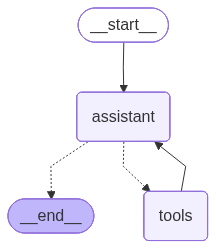

In [17]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Graph visualisation requires extra dependencies -- skipping)")

## Chat Helper Function

Use `chat()` to talk to the profiling agent.
Use the same `thread_id` to continue a conversation.

In [18]:
def chat(user_input: str, thread_id: str = "default") -> str:
    """
    Chat with the portfolio designer agent.

    Args:
        user_input: Your message
        thread_id: Conversation ID (use same ID to continue conversation)

    Returns:
        Agent's response
    """
    config = {"configurable": {"thread_id": thread_id}}

    result = None
    for event in graph.stream(
        {"messages": [HumanMessage(content=user_input)]},
        config,
        stream_mode="values",
    ):
        result = event

    return result["messages"][-1].content


print("Portfolio Designer ready!")
print("\nUsage: chat('your question here')")
print("Use same thread_id to continue conversation")

Portfolio Designer ready!

Usage: chat('your question here')
Use same thread_id to continue conversation


## Demo: Portfolio Construction Queries

Each demo sends a portfolio construction query to the agent.
The agent will either ask profiling questions or move straight
to portfolio design depending on how much info the user provides.

In [19]:
# Demo 1: Open-ended portfolio request
print("=" * 70)
print("Demo 1: Help me build a long-term portfolio.")
print("=" * 70)

print("\nUser: Help me build a long-term portfolio.")
response = chat("Help me build a long-term portfolio.", thread_id="demo1")
print(f"\nBot: {response}")

Demo 1: Help me build a long-term portfolio.

User: Help me build a long-term portfolio.

Bot: Great! To help build a long-term portfolio tailored to you, I’d like to understand a bit more about your preferences and situation.

First, could you tell me:
1. What is your investment time horizon? (e.g., 5, 10, 20+ years)
2. How would you describe your risk tolerance? (conservative, moderate, aggressive)
3. What are your primary investment goals? (growth, income, capital preservation)

Feel free to share any other details you think are relevant!


In [20]:
# Demo 2: Detailed profile upfront
print("=" * 70)
print("Demo 2: Detailed profile upfront")
print("=" * 70)

print("\nUser: I am 45, moderate risk, retiring in 15 years -- what allocation should I use?")
response = chat(
    "I am 45, moderate risk, retiring in 15 years -- what allocation should I use?",
    thread_id="demo2",
)
print(f"\nBot: {response}")

Demo 2: Detailed profile upfront

User: I am 45, moderate risk, retiring in 15 years -- what allocation should I use?

Bot: Thanks for sharing that! With a 15-year time horizon and moderate risk tolerance, your portfolio can balance growth and some capital preservation. To tailor the allocation better, could you tell me:

1. What are your primary investment goals? (e.g., growth, income, capital preservation)
2. Do you prefer investing in ETFs, individual stocks, or a mix of both?
3. Are there any sectors you want to emphasize or avoid?

This will help me design a portfolio that fits your preferences.


In [21]:
# Demo 3: Sector preference
print("=" * 70)
print("Demo 3: Healthcare sector focus")
print("=" * 70)

print("\nUser: How should I diversify if I want strong healthcare exposure?")
response = chat(
    "How should I diversify if I want strong healthcare exposure?",
    thread_id="demo3",
)
print(f"\nBot: {response}")

Demo 3: Healthcare sector focus

User: How should I diversify if I want strong healthcare exposure?

Bot: Great! To help you build a diversified portfolio with strong healthcare exposure, I’d like to understand a bit more about your overall investment profile. 

Could you please tell me:
1. What is your investment time horizon? (e.g., 5, 10, 20+ years)
2. What is your risk tolerance? (conservative, moderate, aggressive)
3. What are your primary investment goals? (growth, income, capital preservation)

This will help me tailor the healthcare exposure and the rest of your portfolio accordingly.


In [22]:
# Demo 4: Dual objective
print("=" * 70)
print("Demo 4: Income + Growth")
print("=" * 70)

print("\nUser: I want income + growth -- how should I allocate?")
response = chat(
    "I want income + growth -- how should I allocate?",
    thread_id="demo4",
)
print(f"\nBot: {response}")

Demo 4: Income + Growth

User: I want income + growth -- how should I allocate?

Bot: Great! To help you best with an income plus growth portfolio, I’d like to understand a bit more about your situation and preferences. 

Could you tell me:
1. What is your investment time horizon? (e.g., 5, 10, 20+ years)
2. How would you describe your risk tolerance? (conservative, moderate, aggressive)
3. Do you prefer investing in ETFs, individual stocks, bonds, or a mix? 

This will help me tailor the allocation to your needs.


In [23]:
# Demo 5: ETF-focused
print("=" * 70)
print("Demo 5: ETF recommendation")
print("=" * 70)

print("\nUser: What ETF mix would you recommend for someone like me?")
response = chat(
    "What ETF mix would you recommend for someone like me?",
    thread_id="demo5",
)
print(f"\nBot: {response}")

Demo 5: ETF recommendation

User: What ETF mix would you recommend for someone like me?

Bot: I'd be happy to help you design an ETF portfolio! To tailor the recommendations to your needs, could you please share a bit about yourself? For example:

- What is your investment time horizon? (e.g., 5, 10, 20+ years)
- How would you describe your risk tolerance? (conservative, moderate, aggressive)
- What are your primary investment goals? (growth, income, capital preservation)

Feel free to share any other preferences or details you think are relevant!


In [24]:
# Demo 6: Specific allocation question
print("=" * 70)
print("Demo 6: Bond allocation")
print("=" * 70)

print("\nUser: How much should I allocate to bonds?")
response = chat(
    "How much should I allocate to bonds?",
    thread_id="demo6",
)
print(f"\nBot: {response}")

Demo 6: Bond allocation

User: How much should I allocate to bonds?

Bot: To help determine how much you should allocate to bonds, I need to understand a bit more about your investment profile. Could you please share:

1. Your age or approximate retirement timeline?
2. Your risk tolerance (conservative, moderate, aggressive)?
3. Your primary investment goals (growth, income, capital preservation)?

This will help me tailor the bond allocation recommendation to your specific situation.


## Verify Saved Portfolio

Check that the last generated portfolio was saved correctly
and matches the schema expected by Notebooks 12-14.

In [25]:
if os.path.exists(PORTFOLIO_FILE):
    with open(PORTFOLIO_FILE) as f:
        saved = json.load(f)
    print(f"Portfolio: {saved['name']}")
    print(f"Description: {saved['description']}")
    print(f"Holdings: {len(saved['holdings'])}")
    total = sum(h['allocation_pct'] for h in saved['holdings'])
    print(f"Total allocation: {total:.1f}%")
    print()
    for h in saved['holdings']:
        print(f"  {h['ticker']:<6} {h['allocation_pct']:>5.1f}%  "
              f"{h['company_name']} ({h['investment_type']})")
    print(f"\nNotebooks 12-14 can now read: {PORTFOLIO_FILE}")
else:
    print(f"No portfolio file found at {PORTFOLIO_FILE}")
    print("The agent has not generated a portfolio yet.")
    print("Continue the conversation to provide enough profile info.")

No portfolio file found at ../data/outputs/portfolio.json
The agent has not generated a portfolio yet.
Continue the conversation to provide enough profile info.


## Interactive Chat

Free-form profiling session. The agent will ask about your investor
profile and generate a portfolio. Type `quit` or `exit` to stop.

In [26]:
print("=" * 70)
print("PORTFOLIO DESIGNER")
print("=" * 70)
print("Tell me about your investment goals and I'll design a portfolio.")
print("Type 'quit' or 'exit' to stop.")
print("=" * 70)

while True:
    user_input = input("\nYou: ").strip()
    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit", "q"):
        print("\nChat ended.")
        break

    response = chat(user_input, thread_id="interactive")
    print(f"\nAI: {response}")

PORTFOLIO DESIGNER
Tell me about your investment goals and I'll design a portfolio.
Type 'quit' or 'exit' to stop.

AI: Hello! I'm here to help you build a personalized investment portfolio. To get started, could you please tell me a bit about your investment goals? For example, are you looking for growth, income, or capital preservation? Also, what is your investment time horizon—how long do you plan to keep your investments before needing the money?

AI: No problem! If you want to start building your investment portfolio later or have any questions, just let me know. I'm here to help whenever you're ready!


KeyboardInterrupt: Interrupted by user

## Summary

- **Portfolio Designer** with a tool-calling LangGraph loop
- **Conversational profiling**: asks about risk tolerance, goals, timeline
- **Web search tool**: current market data via Serper API
- **Portfolio generation tool**: saves structured JSON to disk
- **Thread-based memory**: `MemorySaver` for multi-turn conversations

### Architecture
```
assistant <------+
   |              |
  tools? -----> ToolNode
   |                    
  END
```

### Tools
| Tool | Purpose | API |
|------|---------|-----|
| `search_web` | Current market data, ETF info | Serper (Google Search) |
| `portfolio_generation` | Save portfolio to JSON | Local file I/O |

### Output Contract
```json
{
    "name": "Portfolio Name",
    "description": "Strategy description",
    "holdings": [
        {
            "ticker": "VTI",
            "company_name": "Vanguard Total Stock Market ETF",
            "allocation_pct": 30.0,
            "investment_type": "ETF",
            "rationale": "Broad US equity exposure"
        }
    ]
}
```
Saved to: `../data/outputs/portfolio.json`

### Three-Agent System
```
Notebook 11 (Designer) ->  portfolio.json  ->  Notebook 12 (Analytics)
                       ->  portfolio.json  ->  Notebook 13 (Education)
                       ->  portfolio.json  ->  Notebook 14 (Hub)
```

### Key Differences from Other Notebooks
| Feature | NB 11 (This) | NB 12 (Analytics) | NB 13 (Education) |
|---------|-------------|-------------------|-------------------|
| Graph shape | Agent loop | Linear (5 nodes) | Linear (2 nodes) |
| LLM calls | Multiple per conversation | 1-2 (one-shot) | 1 per turn |
| Tools | search_web, portfolio_generation | None | None |
| Conditional edges | Yes (tool loop) | No | No |
| Output | portfolio.json | Analysis report | Chat responses |
| Interaction | Multi-turn profiling | One-shot pipeline | Multi-turn education |